In [91]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import umap
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import matplotlib as mpl
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import os
import logging
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

In [92]:
import sys

path_to_inspire_parent = "/opt/INSPIRE/"

if path_to_inspire_parent not in sys.path:
    sys.path.append(path_to_inspire_parent)

import INSPIRE

In [93]:
def categorical_scatter(ax, x, y, values, title: str, size: float) -> None:
    vals = pd.Series(values).astype(str).fillna("NA")
    categories = sorted(vals.unique())
    cmap = plt.get_cmap("tab20", max(1, len(categories)))
    for i, cat in enumerate(categories):
        mask = vals.to_numpy() == cat
        ax.scatter(x[mask], y[mask], s=size, c=[cmap(i)], label=cat, linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    if len(categories) <= 14:
        ax.legend(markerscale=3, fontsize=5, frameon=False, loc="best")


def continuous_scatter(ax, x, y, values, title: str, size: float) -> None:
    sca = ax.scatter(x, y, s=size, c=values, cmap="viridis", linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(sca, ax=ax, fraction=0.046, pad=0.02)


def plot_outputs(adata_full, outdir):
    outdir.mkdir(parents=True, exist_ok=True)
    xy = adata_full.obsm["spatial"]
    #raw = adata_full.obsm["spatial_raw"]
    size = min(3.5, max(0.3, 60000.0 / max(adata_full.n_obs, 1)))

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    categorical_scatter(axes[0, 0], xy[:, 0], xy[:, 1], adata_full.obs["sample_id"], "slice", size)
    categorical_scatter(axes[0, 1], xy[:, 0], xy[:, 1], adata_full.obs.get("manual_layer", "NA"), "manual_layer", size)
    categorical_scatter(axes[1, 0], xy[:, 0], xy[:, 1], adata_full.obs.get("region", "NA"), "region", size)
    categorical_scatter(
        axes[1, 1],
        xy[:, 0],
        xy[:, 1],
        adata_full.obs["dominant_spatial_factor"],
        "dominant INSPIRE factor",
        size,
    )
    fig.savefig(outdir / "combined_spatial_overview.png", dpi=250)
    plt.close(fig)

    um = adata_full.obsm["X_umap"]
    fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
    categorical_scatter(axes[0, 0], um[:, 0], um[:, 1], adata_full.obs["sample_id"], "UMAP: slice", size)
    categorical_scatter(axes[0, 1], um[:, 0], um[:, 1], adata_full.obs.get("manual_layer", "NA"), "UMAP: manual_layer", size)
    categorical_scatter(axes[1, 0], um[:, 0], um[:, 1], adata_full.obs.get("region", "NA"), "UMAP: region", size)
    categorical_scatter(axes[1, 1], um[:, 0], um[:, 1], adata_full.obs["INSPIRE_louvain"], "UMAP: INSPIRE_louvain", size)
    fig.savefig(outdir / "umap_metadata.png", dpi=250)
    plt.close(fig)

    factor_cols = [c for c in adata_full.obs.columns if c.startswith("Proportion of spatial factor ")]
    for sample in adata_full.obs["slice"].astype(str).unique():
        mask = adata_full.obs["slice"].astype(str).to_numpy() == sample
        x = xy[mask, 0]
        y = xy[mask, 1]
        obs = adata_full.obs.loc[mask]

        fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
        categorical_scatter(axes[0, 0], x, y, obs.get("manual_layer", "NA"), f"{sample}: manual_layer", size)
        categorical_scatter(axes[0, 1], x, y, obs.get("region", "NA"), f"{sample}: region", size)
        categorical_scatter(axes[1, 0], x, y, obs["dominant_spatial_factor"], f"{sample}: dominant factor", size)
        categorical_scatter(axes[1, 1], x, y, obs["INSPIRE_louvain"], f"{sample}: INSPIRE_louvain", size)
        fig.savefig(outdir / f"{sample}_metadata_spatial.png", dpi=250)
        plt.close(fig)

        n_plot = min(6, len(factor_cols))
        fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
        axes = axes.ravel()
        for i in range(n_plot):
            continuous_scatter(axes[i], x, y, obs[factor_cols[i]].to_numpy(), f"{sample}: factor {i + 1}", size)
        for i in range(n_plot, len(axes)):
            axes[i].axis("off")
        fig.savefig(outdir / f"{sample}_factor_spatial_top6.png", dpi=250)
        plt.close(fig)


In [94]:
def sample_name(path: str) -> str:
    name = Path(path).name
    suffix = "_b100_filtered.h5ad"
    return name[: -len(suffix)] if name.endswith(suffix) else Path(path).stem

def sample_short_name_from_ann(path: str) -> str:
    name = Path(path).name
    suffix = "_b100_anno.csv"
    return name[:5] if name.endswith(suffix) else Path(path).stem


In [95]:
METADATA = ["/opt/INSPIRE/meta/data/annotation/v2_251209/T1098_MT69_3M_Visual_Sub-CTX_V12_b100_anno.csv",
       "/opt/INSPIRE/meta/data/annotation/v2_251209/T1090_MT65_P0_Visual_Sub-CTX_b100_anno.csv",
       "/opt/INSPIRE/meta/data/annotation/v2_251209/T1091_MT64_P32_Visual_Sub-CTX_V12_b100_anno.csv"]


In [ ]:
n_factors=20
adata_full = sc.read_h5ad(f'/opt/INSPIRE/work/adata_full_n{n_factors}.h5ad')

In [71]:
## Add metadata
adata_full.obs['region'] = ''
adata_full.obs['manual_layer'] = ''

for sample, sample_meta in zip(sorted(adata_full.obs["sample_id"].astype(str).unique()), sorted(METADATA)):
    mask = adata_full.obs["sample_id"].astype(str).to_numpy() == sample
    obs_subset = adata_full.obs.loc[mask].copy()
    
    short_name = sample_short_name_from_ann(sample_meta)
    meta = pd.read_csv(sample_meta)
    
    # Create spot identifiers for the subset
    obs_subset['spot_id'] = short_name + '_' + obs_subset.index.str[:-2]
    
    # Merge with metadata
    merged = obs_subset.reset_index().merge(
        meta[['chip_cell', 'region', 'manual_layer']],
        left_on='spot_id',
        right_on='chip_cell',
        how='left'
    )
    
    # Update the original obs
    adata_full.obs.loc[mask, 'region'] = merged['region_y'].values
    adata_full.obs.loc[mask, 'manual_layer'] = merged['manual_layer_y'].values

In [77]:
## compute dominant factor and other necessary things
factor_cols = [c for c in adata_full.obs.columns if c.startswith("Proportion of spatial factor ")]
factor_values = adata_full.obs[factor_cols].to_numpy()
adata_full.obs["dominant_spatial_factor"] = (np.argmax(factor_values, axis=1) + 1).astype(str)

reducer = umap.UMAP(
        n_neighbors=30,
        n_components=2,
        metric="correlation",
        min_dist=0.3,
        random_state=1234,
)
adata_full.obsm["X_umap"] = reducer.fit_transform(adata_full.obsm["latent"]).astype(np.float32)
sc.pp.neighbors(adata_full, use_rep="latent", n_neighbors=30)
sc.tl.louvain(adata_full, key_added="INSPIRE_louvain", resolution=1.0, random_state=1234)


In [78]:
plot_outputs(adata_full, outdir=Path(f'/opt/INSPIRE/work/images/{n_factors}_factors'))

In [97]:
def process_output(n_factors, METADATA):
    adata_full = sc.read_h5ad(f'/opt/INSPIRE/work/adata_full_n{n_factors}.h5ad')
    ## Add metadata
    adata_full.obs['region'] = ''
    adata_full.obs['manual_layer'] = ''
    
    for sample, sample_meta in zip(sorted(adata_full.obs["sample_id"].astype(str).unique()), sorted(METADATA)):
        mask = adata_full.obs["sample_id"].astype(str).to_numpy() == sample
        obs_subset = adata_full.obs.loc[mask].copy()
        
        short_name = sample_short_name_from_ann(sample_meta)
        meta = pd.read_csv(sample_meta)
        
        # Create spot identifiers for the subset
        obs_subset['spot_id'] = short_name + '_' + obs_subset.index.str[:-2]
        
        # Merge with metadata
        merged = obs_subset.reset_index().merge(
            meta[['chip_cell', 'region', 'manual_layer']],
            left_on='spot_id',
            right_on='chip_cell',
            how='left'
        )
        
        # Update the original obs
        adata_full.obs.loc[mask, 'region'] = merged['region_y'].values
        adata_full.obs.loc[mask, 'manual_layer'] = merged['manual_layer_y'].values

            ## compute dominant factor and other necessary things
    factor_cols = [c for c in adata_full.obs.columns if c.startswith("Proportion of spatial factor ")]
    factor_values = adata_full.obs[factor_cols].to_numpy()
    adata_full.obs["dominant_spatial_factor"] = (np.argmax(factor_values, axis=1) + 1).astype(str)
    
    reducer = umap.UMAP(
            n_neighbors=30,
            n_components=2,
            metric="correlation",
            min_dist=0.3,
            random_state=1234,
    )
    adata_full.obsm["X_umap"] = reducer.fit_transform(adata_full.obsm["latent"]).astype(np.float32)
    sc.pp.neighbors(adata_full, use_rep="latent", n_neighbors=30)
    sc.tl.louvain(adata_full, key_added="INSPIRE_louvain", resolution=1.0, random_state=1234)

    #plot_outputs(adata_full, outdir=Path(f'/opt/INSPIRE/work/images/{n_factors}_factors'))
    return adata_full


In [84]:
process_output(n_factors=40, METADATA=METADATA)

AnnData object with n_obs × n_vars = 51097 × 25071
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'sample_id', 'n_genes', 'slice', 'Proportion of spatial factor 1', 'Proportion of spatial factor 2', 'Proportion of spatial factor 3', 'Proportion of spatial factor 4', 'Proportion of spatial factor 5', 'Proportion of spatial factor 6', 'Proportion of spatial factor 7', 'Proportion of spatial factor 8', 'Proportion of spatial factor 9', 'Proportion of spatial factor 10', 'Proportion of spatial factor 11', 'Proportion of spatial factor 12', 'Proportion of spatial factor 13', 'Proportion of spatial factor 14', 'Proportion of spatial factor 15', 'Proportion of spatial factor 16', 'Proportion of spatial factor 17', 'Proportion of spatial factor 18', 'Proportion of spatial factor 19', 'Proportion of spatial factor 20', 'Proportion of spatial factor 21', 'Proportion of spatial factor 22', 'Proportion of spatial factor 23', 'Proportion of spatial factor 24', 'Proportion of spatial factor 25', 

In [98]:
adata_metrics_=[]
for n_f in [20,40,60,80,100]:
    adata_metrics_.append(process_output(n_factors=n_f, METADATA=METADATA))

In [87]:
adata_full.obs

,pct_counts_mt,orig.ident,x,y,sample_id,n_genes,slice,Proportion of spatial factor 1,Proportion of spatial factor 2,Proportion of spatial factor 3,...,Proportion of spatial factor 15,Proportion of spatial factor 16,Proportion of spatial factor 17,Proportion of spatial factor 18,Proportion of spatial factor 19,Proportion of spatial factor 20,region,manual_layer,dominant_spatial_factor,INSPIRE_louvain
65712999635800-0,1.487414,sample,15300,7000,T1098_MT69_3M_Visual_Sub-CTX_V12_b100_filtered,5179,0,0.002572,0.012016,0.006149,...,0.014441,0.241530,0.028058,0.004095,0.104076,0.287376,V1,L2,20,10
47244640269300-0,1.617095,sample,11000,13300,T1098_MT69_3M_Visual_Sub-CTX_V12_b100_filtered,5235,0,0.001537,0.014938,0.029961,...,0.019551,0.066684,0.015517,0.007416,0.005925,0.030828,V1,L4,6,9
40372692597800-0,1.849376,sample,9400,15400,T1098_MT69_3M_Visual_Sub-CTX_V12_b100_filtered,4184,0,0.066897,0.037157,0.030428,...,0.002064,0.005471,0.295325,0.202658,0.044194,0.006281,V26,WM,17,6
33930241656000-0,1.704715,sample,7900,17600,T1098_MT69_3M_Visual_Sub-CTX_V12_b100_filtered,4504,0,0.022928,0.022023,0.045760,...,0.068167,0.084339,0.041006,0.045368,0.122802,0.017878,V26,L3,5,0
72155450583100-0,1.438677,sample,16800,10300,T1098_MT69_3M_Visual_Sub-CTX_V12_b100_filtered,5085,0,0.001927,0.015460,0.066177,...,0.092052,0.020912,0.013671,0.003539,0.074131,0.213532,V26,L4,20,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57982058511700-2,1.711706,sample,13500,15700,T1091_MT64_P32_Visual_Sub-CTX_V12_b100_filtered,5909,2,0.011281,0.011057,0.024124,...,0.253089,0.015338,0.017567,0.004738,0.034941,0.024928,remove,L3,15,5
58841051962800-2,1.317788,sample,13700,7600,T1091_MT64_P32_Visual_Sub-CTX_V12_b100_filtered,6867,2,0.005953,0.011943,0.015141,...,0.035152,0.102999,0.003693,0.014543,0.032486,0.147057,V1,L3,9,10
32212254730300-2,1.424940,sample,7500,10300,T1091_MT64_P32_Visual_Sub-CTX_V12_b100_filtered,6039,2,0.048874,0.016958,0.038399,...,0.004981,0.006311,0.023061,0.594753,0.009782,0.009860,V1,WM,18,6
32641751458600-2,1.413686,sample,7600,9000,T1091_MT64_P32_Visual_Sub-CTX_V12_b100_filtered,6233,2,0.047412,0.006719,0.035798,...,0.002973,0.012019,0.060521,0.109046,0.016104,0.021555,V1,L6,10,1


## Compute metrics 

INSPIRE_louvain     0     1     2     3     4     5     6     7     8     9  \
manual_layer                                                                  
L1                 54     2   627    26  3072     2    31    70    33     2   
L2                 42     1  3791  2008   860    14     2  2230     7    21   
L3                 77     0   457  2352    25   470     0  1306     1   375   
L4                419     0    22   260     0  2902     0    85     0  2723   
L5               5185   655     9    22     4   495     3     2    44   120   
L6                905  4331     1     1    10     2   320     2  1588     0   
WM                 30   173     0     0    32     0  3351     0  1582     0   

INSPIRE_louvain    10    11    12  
manual_layer                       
L1                  0  1078    28  
L2               1114   805  1685  
L3               1726   565   431  
L4                214    77    49  
L5                  0    52     0  
L6                  0    24     0  


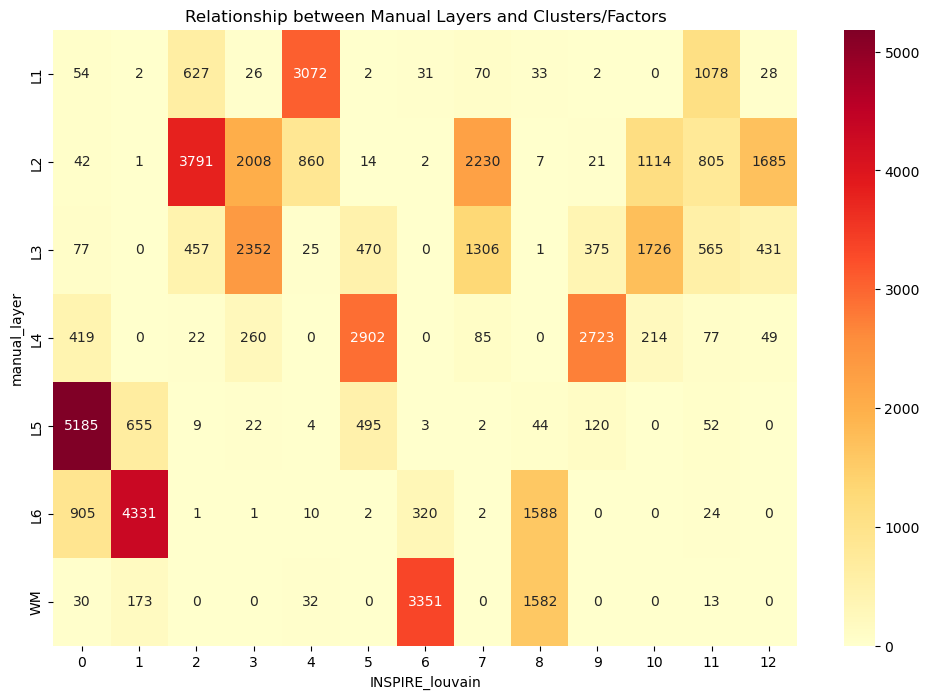

In [102]:
#MANUAL  MAPPING
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
adata_full=adata_metrics_[0]
#Create a cross-tabulation to see the relationship
crosstab = pd.crosstab(adata_full.obs['manual_layer'], adata_full.obs['INSPIRE_louvain'])  # or your factor column
print(crosstab)

#Visualize as heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Relationship between Manual Layers and Clusters/Factors')
plt.savefig('matrix.png')

plt.show()


In [ ]:
## based on classification

In [ ]:
## based on dominant factor